## Capstone Project of RML (Group 4) - HMDA dataset 

### Pre-modeling 

#### 1.	Data inspection

In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [3]:
import pandas as pd

# Load local dataset
file_path = "2024_lar.txt"
raw_data = pd.read_csv(file_path, sep="|")

# Number of rows
raw_data.shape[0]

12259112

In [4]:
raw_data.head(10)

,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,254900ZFWS2106HWPH46,41884,CA,6075.0,6075026303,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4632,89.83,184200,62.0,1015,1242,72
1,2024,254900ZFWS2106HWPH46,99999,IN,18093.0,18093951202,C,VA:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,NaN,NaN,NaN,2528,5.26,81800,117.0,1074,1334,27
2,2024,254900ZFWS2106HWPH46,33340,WI,55089.0,55089630201,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4565,7.78,102100,104.0,1576,1726,52
3,2024,254900ZFWS2106HWPH46,14860,CT,9120.0,9120080500,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3107,13.32,146500,75.0,1248,1397,64
4,2024,254900ZFWS2106HWPH46,11694,VA,51153.0,51153901233,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,7347,37.84,164200,129.0,2098,2154,27
5,2024,254900ZFWS2106HWPH46,36740,FL,12095.0,12095016603,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,7516,50.68,90400,123.0,1865,2572,17
6,2024,254900ZFWS2106HWPH46,15804,NJ,34007.0,34007603504,C,VA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,2688,29.39,117400,154.0,966,977,57
7,2024,254900ZFWS2106HWPH46,34980,TN,47165.0,47165021005,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,6063,19.21,101700,118.0,1577,2069,33
8,2024,254900ZFWS2106HWPH46,12054,GA,13063.0,13063040521,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3329,93.03,100900,45.0,501,963,50
9,2024,254900ZFWS2106HWPH46,19124,TX,48121.0,48121021722,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4150,35.23,110300,116.0,1005,1374,31


In [5]:
list(raw_data.columns)

['activity_year',
 'lei',
 'derived_msa_md',
 'state_code',
 'county_code',
 'census_tract',
 'conforming_loan_limit',
 'derived_loan_product_type',
 'derived_dwelling_category',
 'derived_ethnicity',
 'derived_race',
 'derived_sex',
 'action_taken',
 'purchaser_type',
 'preapproval',
 'loan_type',
 'loan_purpose',
 'lien_status',
 'reverse_mortgage',
 'open_end_line_of_credit',
 'business_or_commercial_purpose',
 'loan_amount',
 'combined_loan_to_value_ratio',
 'interest_rate',
 'rate_spread',
 'hoepa_status',
 'total_loan_costs',
 'total_points_and_fees',
 'origination_charges',
 'discount_points',
 'lender_credits',
 'loan_term',
 'prepayment_penalty_term',
 'intro_rate_period',
 'negative_amortization',
 'interest_only_payment',
 'balloon_payment',
 'other_nonamortizing_features',
 'property_value',
 'construction_method',
 'occupancy_type',
 'manufactured_home_secured_property_type',
 'manufactured_home_land_property_interest',
 'total_units',
 'multifamily_affordable_units',
 'in

In [6]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12259112 entries, 0 to 12259111
Data columns (total 99 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       object 
 2   derived_msa_md                            int64  
 3   state_code                                object 
 4   county_code                               float64
 5   census_tract                              object 
 6   conforming_loan_limit                     object 
 7   derived_loan_product_type                 object 
 8   derived_dwelling_category                 object 
 9   derived_ethnicity                         object 
 10  derived_race                              object 
 11  derived_sex                               object 
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  

#### 2.	Target construction

We construct a binary target variable based on the `action_taken` field, where approved applications (values 1 and 2) are labeled as 1, and denied applications (value 3) are labeled as 0. All other categories are excluded to ensure a clean binary classification setup.

In [9]:
import numpy as np

# Create a copy of the original dataset to avoid modifying raw data
df = raw_data.copy()

# Step 1: Filter the dataset to keep only relevant action_taken values
# Keep:
# 1 = Loan originated
# 2 = Approved but not accepted
# 3 = Denied
# Remove all other categories (e.g., withdrawn, incomplete, etc.)
df = df[df["action_taken"].isin([1, 2, 3])]

# Step 2: Create a binary target variable
# Approved (1, 2) → 1
# Denied (3) → 0
df["target"] = np.where(
    df["action_taken"].isin([1, 2]),  # approved cases
    1,
    0  # denied cases
)

# Step 3: Check the distribution of the target variable
# This helps us understand class balance (approved vs denied)
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

target
1    6558283
0    2103456
Name: count, dtype: int64
target
1    0.757155
0    0.242845
Name: proportion, dtype: float64



The constructed target variable shows that approximately 75.7% of applications are approved, while 24.3% are denied. This class imbalance reflects real-world lending patterns, where approvals are more frequent than denials. This imbalance has important implications for both model performance and fairness evaluation. In particular, a model may achieve high accuracy by favoring the majority class, while still performing poorly on denied cases. As a result, it is critical to examine error rates such as false positive rate (FPR) and false negative rate (FNR), especially across different demographic groups, in subsequent analysis.

#### 3. Data cleaning

**Converting values into `NaN`** 

In this dataset, values such as "NA" and "Exempt" represent missing or non-applicable information, but they are stored as text rather than true missing values. Since Python does not automatically recognize these strings as missing, they may be mistakenly treated as valid data or distinct categories. This can distort both statistical analysis and model training.

Therefore, we convert these values into `NaN`, which allows the system to correctly identify them as missing. This step is important for ensuring accurate calculation of missingness and for maintaining data quality in later stages of the analysis.

In [11]:
df = df.replace(["NA", "Exempt"], np.nan)

**Identifying Missing Values**

After converting "NA" and "Exempt" into `NaN`, we calculate the proportion of missing values for each column. This allows us to clearly see how much data is missing in each feature. By sorting the results, we can easily identify columns with very high missing rates, which may need to be removed or handled carefully in later steps.

In [13]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

co_applicant_ethnicity_5        0.999996
co_applicant_ethnicity_4        0.999988
applicant_ethnicity_5           0.999988
applicant_ethnicity_4           0.999960
co_applicant_race_5             0.999913
applicant_race_5                0.999785
co_applicant_race_4             0.999763
co_applicant_ethnicity_3        0.999541
applicant_race_4                0.999362
applicant_ethnicity_3           0.998645
co_applicant_race_3             0.998397
denial_reason_4                 0.998200
multifamily_affordable_units    0.997217
applicant_race_3                0.995576
aus_5                           0.991795
aus_4                           0.990886
denial_reason_3                 0.990197
total_points_and_fees           0.987652
aus_3                           0.981436
co_applicant_race_2             0.978635
dtype: float64

**Dropping Columns with More Than 90% Missing Values**

To ensure data quality, we remove columns with excessive missingness. Specifically, we identify all columns where more than 90% of the values are missing and drop them from the dataset.

This step helps eliminate features that provide little useful information and could negatively impact model performance or analysis results. By retaining only columns with sufficient data, we create a more robust and reliable dataset for further processing.

In [14]:
cols_to_drop = missing[missing > 0.9].index
df = df.drop(columns=cols_to_drop)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8661739 entries, 1 to 12259110
Data columns (total 74 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       object 
 2   derived_msa_md                            int64  
 3   state_code                                object 
 4   county_code                               float64
 5   census_tract                              object 
 6   conforming_loan_limit                     object 
 7   derived_loan_product_type                 object 
 8   derived_dwelling_category                 object 
 9   derived_ethnicity                         object 
 10  derived_race                              object 
 11  derived_sex                               object 
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  preapp

**Data Type Conversion**

In this step, we adjust the data types of selected variables to better reflect their actual meaning.

For variables such as `income` and `loan_amount`, although they look like numbers, they are stored as strings due to the presence of values like "NA" or "Exempt". If we do not convert them, numerical operations may fail or produce incorrect results. Therefore, we convert these columns into numeric types, allowing proper calculations in later analysis.

For variables such as `derived_race`, `derived_ethnicity`, and `derived_sex`, they are clearly categorical in nature. Even though they are stored as object types, this does not explicitly indicate that they are categories. By converting them to `category`, we ensure they are properly recognized as grouped variables, which is important for fairness analysis and for encoding in the modeling stage.

This step helps ensure that the dataset is correctly structured for further analysis and modeling.

In [17]:
# Convert numeric variables
df["income"] = pd.to_numeric(df["income"], errors="coerce")
df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")

# Convert categorical variables
cat_cols = ["derived_race", "derived_ethnicity", "derived_sex"]
for col in cat_cols:
    df[col] = df[col].astype("category")

#### 4.	Baseline fairness analysis (pre-model)

Before building the model, we first examine fairness in the raw data by comparing approval rates across different demographic groups, including race, ethnicity, and sex.

These variables represent key protected attributes, and analyzing them helps us understand whether there are existing disparities in lending outcomes. If certain groups have consistently lower approval rates, this may indicate potential bias or structural differences in the data.

This step is important because it allows us to separate data-driven disparities from model-driven bias. By establishing a baseline, we can later evaluate whether the model reduces, preserves, or amplifies these differences.

Therefore, pre-model fairness analysis is a critical step in responsible machine learning, as it provides essential context for interpreting model results.

In [20]:
df.groupby("derived_race")["target"].mean().sort_values()

derived_race
Free Form Text Only                          0.410526
Native Hawaiian or Other Pacific Islander    0.613013
2 or more minority races                     0.619721
American Indian or Alaska Native             0.629663
Black or African American                    0.633430
Race Not Available                           0.722380
White                                        0.781922
Asian                                        0.787291
Joint                                        0.804578
Name: target, dtype: float64

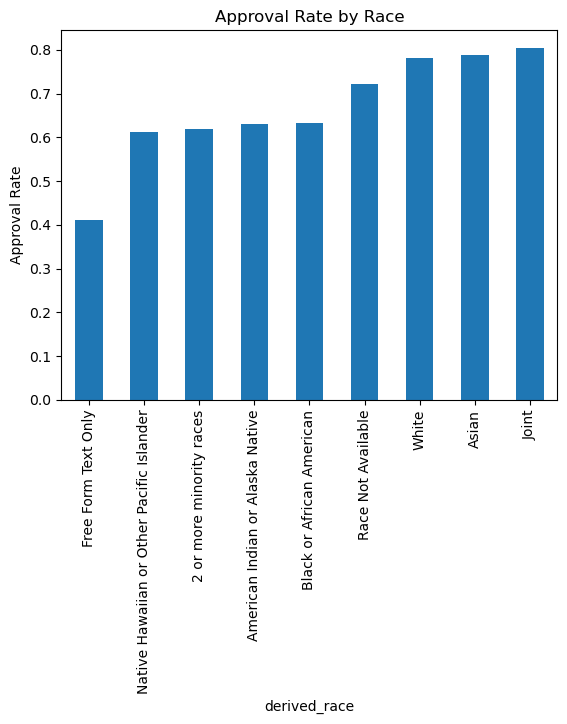

In [19]:
import matplotlib.pyplot as plt

df.groupby("derived_race")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Race")
plt.show()

**Approval Rate by Race**

The approval rate varies significantly across racial groups, indicating the presence of disparities in the raw data. In particular, applicants identified as White and Asian exhibit higher approval rates compared to other groups such as Black or African American. Additionally, the "Joint" category, which represents applications involving multiple applicants, shows one of the highest approval rates. This may reflect stronger combined financial profiles rather than group-specific effects. On the other hand, the "Free Form Text Only" category has a notably lower approval rate. Since this category represents non-standard or self-reported entries, it may reflect data quality issues or incomplete demographic information. Overall, these results suggest that disparities exist across racial groups even before modeling, highlighting the importance of further fairness analysis.

In [23]:
df.groupby("derived_ethnicity")["target"].mean()

derived_ethnicity
Ethnicity Not Available    0.729368
Free Form Text Only        0.514610
Hispanic or Latino         0.695343
Joint                      0.792613
Not Hispanic or Latino     0.773476
Name: target, dtype: float64

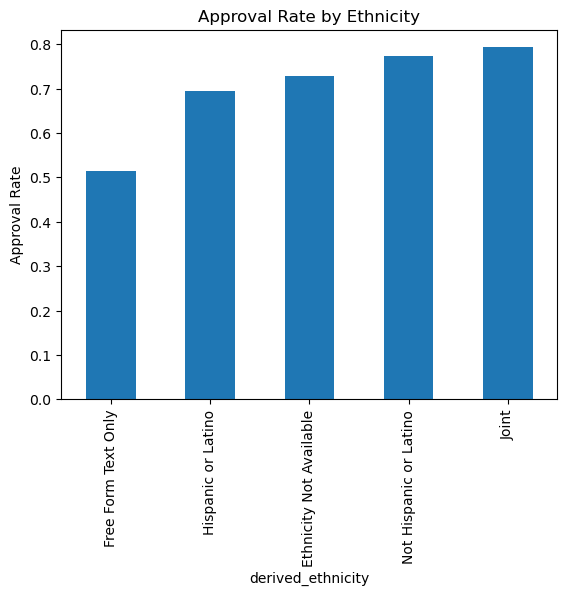

In [24]:
df.groupby("derived_ethnicity")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Ethnicity")
plt.show()

**Approval Rate by Ethnicity**

Approval rates differ across ethnicity groups, with "Not Hispanic or Latino" and "Joint" categories showing higher approval rates compared to "Hispanic or Latino" and "Free Form Text Only". The "Joint" category again reflects applications with multiple applicants, which may lead to stronger financial qualifications and therefore higher approval rates. The lower approval rate observed for the "Free Form Text Only" group may be due to incomplete or non-standard reporting of ethnicity, which can affect both data quality and interpretation. These differences suggest that ethnicity-related disparities may exist in the dataset and should be carefully examined in further analysis.

In [22]:
df.groupby("derived_sex")["target"].mean()

derived_sex
Female               0.707112
Joint                0.816700
Male                 0.735659
Sex Not Available    0.733773
Name: target, dtype: float64

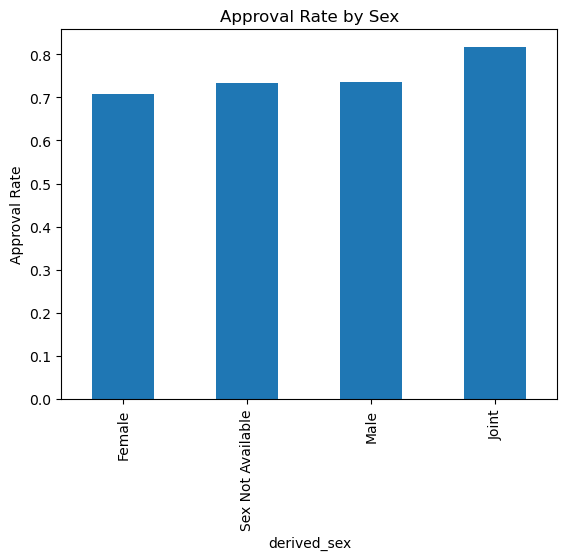

In [25]:
df.groupby("derived_sex")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Sex")
plt.show()

**Approval Rate by Sex**

Approval rates across sex categories appear relatively similar, with only modest differences between male and female applicants. However, the "Joint" category again shows a higher approval rate, likely reflecting the presence of multiple applicants and potentially stronger combined financial profiles. The "Sex Not Available" group also appears, which may indicate missing or unreported information. This highlights potential data quality limitations that should be considered when interpreting results. Overall, compared to race and ethnicity, disparities across sex appear less pronounced in the raw data.

**Examining Control Variables**

To better understand whether observed disparities in approval rates are driven by legitimate financial factors, we examine key control variables such as income and debt-to-income (DTI) ratio across different racial groups. These variables are commonly used in lending decisions and reflect applicants’ financial capacity and risk.

By analyzing these factors, we aim to distinguish whether differences in approval rates are due to underlying financial characteristics or whether disparities persist even after accounting for these variables, which may indicate potential bias.

In [27]:
df.groupby("derived_race").agg({
    "income": "mean",
    "target": "mean"
})

,income,target
derived_race,,
2 or more minority races,2478.580259,0.619721
American Indian or Alaska Native,189.597924,0.629663
Asian,223.782925,0.787291
Black or African American,312.504156,0.633430
Free Form Text Only,117.999535,0.410526
Joint,186.673917,0.804578
Native Hawaiian or Other Pacific Islander,136.327801,0.613013
Race Not Available,169.927337,0.722380
White,163.145481,0.781922


**Comparing Approval Rates and Income Across Racial Groups**

The results show clear differences in approval rates across racial groups. For example, White and Asian applicants have relatively high approval rates (around 78–79%), while Black or African American applicants have a lower approval rate (around 63%).

Interestingly, these differences are not fully explained by income levels. In particular, the Black or African American group has the highest average income among all groups, yet its approval rate remains lower than that of White and Asian applicants. This suggests that income alone does not fully account for the observed disparities.

However, these results should be interpreted with caution. At this stage, we have not yet controlled for other important factors such as debt-to-income ratio, loan type, or other risk-related variables. Therefore, while the findings indicate the presence of disparities in the data, they do not necessarily imply bias.

Further analysis is needed to determine whether these differences are driven by legitimate financial factors or potential unfair treatment.

In [37]:
import numpy as np

def dti_to_numeric(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    
    if "<20%" in x:
        return 15
    elif "20%-<30%" in x:
        return 25
    elif "30%-<36%" in x:
        return 33
    elif "36" in x and "%" in x:
        return 36
    elif "50%-60%" in x:
        return 55
    elif ">60%" in x:
        return 65
    
    try:
        return float(x)
    except:
        return np.nan

**Handling and Simplifying Debt-to-Income Ratio (DTI)**

The original `debt_to_income_ratio` variable contains a mixture of formats, including both numeric values (e.g., 40.0, 45.0) and categorical ranges (e.g., "20%-<30%", "50%-60%"). This makes the data inconsistent and difficult to interpret directly, especially when comparing financial risk across groups.

To improve readability and analysis, we aim to group DTI into a small number of meaningful categories (e.g., <30%, 30–40%, 40–50%, etc.) and examine how these risk levels relate to approval rates.

However, in order to classify values using conditional statements (e.g., `if x < 30`), the data must first be in numeric form. Since the original variable includes both numbers and string-based ranges, a direct conversion to numeric would result in many values being converted to `NaN`, causing significant information loss.

To address this, we first map each range-based value to a representative numeric value (e.g., "30%-<36%" → 33). This step allows us to preserve the relative meaning of each range while converting all values into a consistent numeric format.

Once the data is standardized, we can then apply conditional logic to group observations into clearly defined DTI categories, enabling a more structured and interpretable analysis of financial risk and approval outcomes.

In [38]:
df["dti_numeric"] = df["debt_to_income_ratio"].apply(dti_to_numeric)

In [39]:
def simplify_dti(x):
    if pd.isna(x):
        return "Missing"
    
    if x < 30:
        return "<30%"
    elif x < 40:
        return "30-40%"
    elif x < 50:
        return "40-50%"
    elif x < 60:
        return "50-60%"
    else:
        return ">60%"

In [40]:
df["dti_group"] = df["dti_numeric"].apply(simplify_dti)

In [42]:
result = df.groupby(["derived_race", "dti_group"])["target"].mean().unstack()
result["overall_approval_rate"] = df.groupby("derived_race")["target"].mean()
result

dti_group,30-40%,40-50%,50-60%,<30%,>60%,Missing,overall_approval_rate
derived_race,,,,,,,
2 or more minority races,0.771525,0.795628,0.563624,0.558792,0.054297,0.582692,0.619721
American Indian or Alaska Native,0.767349,0.794302,0.556998,0.592345,0.046657,0.612624,0.629663
Asian,0.901438,0.895853,0.543929,0.841224,0.060949,0.756799,0.787291
Black or African American,0.755349,0.782178,0.590037,0.594256,0.056617,0.636871,0.633430
Free Form Text Only,0.628895,0.711221,0.350365,0.447183,0.008532,0.195122,0.410526
Joint,0.879516,0.878217,0.692835,0.835759,0.138678,0.756244,0.804578
Native Hawaiian or Other Pacific Islander,0.771999,0.786864,0.591261,0.604984,0.056678,0.600861,0.613013
Race Not Available,0.831719,0.827933,0.587694,0.759695,0.075564,0.728183,0.722380
White,0.874311,0.867662,0.628879,0.826859,0.096398,0.751141,0.781922


**Comparing Approval Rates and debt_to_income_rate  Across Racial Groups**

To better understand whether approval disparities are driven by financial risk, we examine approval rates across racial groups within the same DTI categories.

Overall, approval rates decrease as DTI increases, which is expected since higher debt-to-income ratios indicate higher financial risk. This suggests that lending decisions are at least partially aligned with risk-based factors.

However, even within the same DTI group, differences across racial groups still exist. In particular, White applicants consistently show relatively high approval rates across most DTI categories. For example, in the 30–40% and 40–50% DTI ranges, White applicants maintain approval rates close to or above 85%, which are among the highest across all groups.

In contrast, some groups, such as Black or African American and "2 or more minority races," tend to have lower approval rates within the same DTI categories. This suggests that differences in financial risk alone do not fully explain the observed disparities.

Overall, these results indicate that while DTI explains part of the variation in approval rates, disparities across racial groups persist even after controlling for financial risk. This may suggest the presence of unequal treatment or unobserved factors, and warrants further investigation in the modeling stage.

### Modeling  

#### 5.	Feature selection

**Model Design and Feature Selection**

To evaluate both predictive performance and fairness, we construct two models with different feature sets.

---

**Model A: Baseline Model (Excluding Protected Attributes)**

Model A includes only financial and loan-related variables that are commonly used in lending decisions:

- **1. income**: Represents the applicant’s repayment ability. Higher income generally indicates lower default risk.

- **2. ebt-to-income ratio (DTI group)**: A key risk indicator reflecting the applicant’s debt burden relative to income.

- **3. loan_term**: Indicates the duration of the loan. Longer terms may be associated with different risk profiles.

- **4. loan_type**: Different loan types (e.g., conventional vs. FHA) have different approval standards and risk characteristics.

- **5. loan_purpose**: Distinguishes between purposes such as home purchase or refinancing, which may affect approval likelihood.

- **6. applicant_credit_score_type**: Indicates the type of credit scoring model used for the applicant. Although it is not the numeric credit score itself, it can still serve as a proxy for credit evaluation differences and may help explain variation in approval patterns or pricing decisions.

- **7. tract_minority_population_percent**: Measures the share of minority residents in the applicant’s census tract. This variable can serve as a neighborhood-level proxy for demographic context and is useful for analyzing potential geographic or structural fairness issues beyond individual protected attributes.

- **8. combined_loan_to_value_ratio**:  Captures the ratio between the loan amount and the property value, directly reflecting the borrower’s leverage level. A higher CLTV indicates that the borrower is financing a larger portion of the property, which typically implies higher credit risk and plays a critical role in underwriting decisions.

- **9. property_value**: Represents the estimated value of the property used as collateral. This feature provides context for the scale of the loan and helps the model assess whether the requested loan amount is reasonable relative to the asset value.


We retain combined **combined_loan-to-value ratio (CLTV)** and **property_value** while excluding **loan_amount** to avoid redundancy. CLTV captures the borrower’s leverage and directly reflects credit risk, while property_value provides contextual information about the scale of the underlying asset. Together, they allow the model to distinguish between relative risk and absolute transaction size, leading to clearer interpretation and more reliable fairness analysis.

We exclude **interest_rate** and **rate_spread** from the main model because they are closely tied to pricing outcomes and may introduce data leakage, as they are not strictly determined before the approval decision. We also exclude **state_code** to avoid capturing broad geographic patterns that may reflect structural or historical disparities rather than individual financial risk. These variables are instead used in post-model analysis, where **interest_rate** and **rate_spread** support pricing fairness evaluation, and **state_code** is used to assess robustness and geographic disparities.

These variables are included because they provide meaningful and justifiable information about financial risk and lending conditions. Model A represents a fairness-aware design that does not directly use protected attributes in decision-making.

---
**Model B: Extended Model (Including Protected Attribute)**

Model B includes all features from Model A, with the addition of:

- **derived_race**: A protected attribute representing the applicant’s race.

This model is not intended for deployment but is used as an analytical tool to examine whether including race improves predictive performance and how it affects fairness. The reason of not adding sex is because we didn't observe the disparity in raw data. 

---

**Purpose of Comparing Two Models**

The goal of constructing these two models is to analyze the trade-off between accuracy and fairness. By comparing Model A and Model B, we can evaluate:

- Whether including race significantly improves predictive accuracy
- Whether it leads to increased disparities across racial groups

In particular, we focus on group-based error metrics such as:

- **False Positive Rate (FPR)**: The rate at which applicants who should be rejected are incorrectly approved
- **False Negative Rate (FNR)**: The rate at which applicants who should be approved are incorrectly rejected

By comparing FPR and FNR across racial groups, we can assess whether the model produces unequal error patterns, which may indicate potential bias.


In [ ]:
from sklearn.model_selection import train_test_split

#features without race 
featuresA = [
    "income",
    "dti_group",
    "loan_term",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value"
    

]
#features with race 
featuresB= featuresA + ["derived_race"]
target = "target"

#### 6. Train-Test Split

We use the same train/test split for both models to ensure a fair comparison. Although Model A and Model B differ in the number of features, they are trained and evaluated on identical data. This allows us to isolate the effect of including the protected attribute and compare performance and fairness metrics more reliably.

**Model A (without race)**

In [93]:
# -----------------------------
# Step 0: define feature types
# -----------------------------
numeric_features_A = [
    "income",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value"
]

categorical_features_A = [
    "dti_group",
    "loan_term",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type"
]

# -----------------------------
# Step 1: clean dtypes in df
# -----------------------------
for col in numeric_features_A:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in categorical_features_A:
    df[col] = df[col].astype("string")

# for Model B
df["derived_race"] = df["derived_race"].astype("string")

# -----------------------------
# Step 2: build X and y
# -----------------------------
X_A = df[featuresA].copy()
y = df[target].astype(int).copy()

# -----------------------------
# Step 3: train/test split
# -----------------------------
X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_A,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# optional check
print(X_train_A.dtypes)
print(X_test_A.dtypes)

print(
    f"Model A → Train: {X_train_A.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test_A.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

income                                      float64
dti_group                            string[python]
loan_term                            string[python]
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
dtype: object
income                                      float64
dti_group                            string[python]
loan_term                            string[python]
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
dtype: object
Model A → Train: (6929391, 9) (6,929

**Model B (without race)**

In [94]:
# Build X
X_B = df[featuresB].copy()

# Use SAME split indices
X_train_B = X_B.loc[X_train_A.index].copy()
X_test_B  = X_B.loc[X_test_A.index].copy()

# Clean dtypes in X_B using same logic as X_A
for col in numeric_features_A:
    X_train_B[col] = pd.to_numeric(X_train_B[col], errors="coerce")
    X_test_B[col]  = pd.to_numeric(X_test_B[col], errors="coerce")

for col in categorical_features_A:
    X_train_B[col] = X_train_B[col].astype("string")
    X_test_B[col]  = X_test_B[col].astype("string")

# Clean derived
X_train_B["derived_race"] = X_train_B["derived_race"].astype("string")
X_test_B["derived_race"]  = X_test_B["derived_race"].astype("string")


# optional check
print(X_train_B.dtypes)
print(X_test_B.dtypes)

print(
    f"Model B → Train: {X_train_B.shape}, "
    f"Test: {X_test_B.shape}"
)

income                                      float64
dti_group                            string[python]
loan_term                            string[python]
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
derived_race                         string[python]
dtype: object
income                                      float64
dti_group                            string[python]
loan_term                            string[python]
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float6

#### 7.  logistic regression (Model A vs Model B)

**Model A**

In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step 4: preprocessing for Model A
# -----------------------------
numeric_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_A, numeric_features_A),
        ("cat", categorical_transformer_A, categorical_features_A)
    ]
)

# -----------------------------
# Step 5: Logistic Regression pipeline
# -----------------------------
model_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

# -----------------------------
# Step 6: fit model
# -----------------------------
model_A.fit(X_train_A, y_train)

# -----------------------------
# Step 7: predictions
# -----------------------------
y_train_pred_A = model_A.predict(X_train_A)
y_test_pred_A = model_A.predict(X_test_A)

# -----------------------------
# Step 8: evaluation
# -----------------------------
train_acc_A = accuracy_score(y_train, y_train_pred_A)
test_acc_A = accuracy_score(y_test, y_test_pred_A)

print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8274
Test Accuracy:  0.8275


In [98]:
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

fairness_A = result_A.groupby("race", dropna=False).apply(compute_metrics)
fairness_A.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.8018,0.5502,0.0415,0.7632
American Indian or Alaska Native,12619.0,0.8208,0.5764,0.0372,0.7647
Asian,104588.0,0.8786,0.5296,0.0265,0.8660
Black or African American,152109.0,0.8129,0.5765,0.0502,0.7569
Free Form Text Only,428.0,0.6028,0.3941,0.0440,0.7360
Joint,38136.0,0.9075,0.6474,0.0289,0.8495
Native Hawaiian or Other Pacific Islander,4247.0,0.7667,0.5103,0.0624,0.7584
Race Not Available,304705.0,0.8562,0.6018,0.0463,0.7997
White,1111212.0,0.8905,0.6121,0.0318,0.8416


**Model B**

In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step 1: build X for Model B
# -----------------------------
X_B = df[featuresB].copy()

# Use the same split indices as Model A
X_train_B = X_B.loc[X_train_A.index].copy()
X_test_B  = X_B.loc[X_test_A.index].copy()

# -----------------------------
# Step 2: define feature types for Model B
# -----------------------------
numeric_features_B = numeric_features_A.copy()

categorical_features_B = categorical_features_A + ["derived_race"]

# optional safety: enforce dtypes again
for col in numeric_features_B:
    X_train_B[col] = pd.to_numeric(X_train_B[col], errors="coerce")
    X_test_B[col]  = pd.to_numeric(X_test_B[col], errors="coerce")

for col in categorical_features_B:
    X_train_B[col] = X_train_B[col].astype("string")
    X_test_B[col]  = X_test_B[col].astype("string")

# -----------------------------
# Step 3: preprocessing for Model B
# -----------------------------
numeric_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_B, numeric_features_B),
        ("cat", categorical_transformer_B, categorical_features_B)
    ]
)

# -----------------------------
# Step 4: Logistic Regression pipeline
# -----------------------------
model_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

# -----------------------------
# Step 5: fit Model B
# -----------------------------
model_B.fit(X_train_B, y_train)

# -----------------------------
# Step 6: predictions
# -----------------------------
y_train_pred_B = model_B.predict(X_train_B)
y_test_pred_B = model_B.predict(X_test_B)

# -----------------------------
# Step 7: evaluation
# -----------------------------
train_acc_B = accuracy_score(y_train, y_train_pred_B)
test_acc_B = accuracy_score(y_test, y_test_pred_B)

print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8286
Test Accuracy:  0.8286


In [100]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_B = model_B.predict(X_test_B)

# Combine results
result_B = X_test_B.copy()
result_B["y_true"] = y_test.values
result_B["y_pred"] = pred_B
result_B["race"] = df.loc[X_test_B.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_B = result_B.groupby("race", dropna=False).apply(compute_metrics)

fairness_B.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.7426,0.4552,0.0784,0.7770
American Indian or Alaska Native,12619.0,0.7604,0.4789,0.0762,0.7759
Asian,104588.0,0.8866,0.5469,0.0210,0.8666
Black or African American,152109.0,0.7631,0.5014,0.0855,0.7620
Free Form Text Only,428.0,0.3715,0.1859,0.3145,0.7664
Joint,38136.0,0.9154,0.6665,0.0237,0.8499
Native Hawaiian or Other Pacific Islander,4247.0,0.7271,0.4526,0.0899,0.7650
Race Not Available,304705.0,0.8384,0.5670,0.0576,0.8012
White,1111212.0,0.9020,0.6374,0.0242,0.8420


**Comparison of Accuracy, FNR, FPR between Model A (without race)and Model B (race)**

In [104]:
fairness_A_renamed = fairness_A.rename(columns={
    "FPR": "FPR_A",
    "FNR": "FNR_A",
    "Accuracy": "Accuracy_A",
    "Approval_Rate": "Approval_Rate_A"
}).drop(columns=["Count"])

fairness_B_renamed = fairness_B.rename(columns={
    "FPR": "FPR_B",
    "FNR": "FNR_B",
    "Accuracy": "Accuracy_B",
    "Approval_Rate": "Approval_Rate_B"
}).drop(columns=["Count"])

comparison_lr = fairness_A_renamed.join(fairness_B_renamed)
comparison_lr.round(4)

,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.8018,0.5502,0.0415,0.7632,0.7426,0.4552,0.0784,0.7770
American Indian or Alaska Native,0.8208,0.5764,0.0372,0.7647,0.7604,0.4789,0.0762,0.7759
Asian,0.8786,0.5296,0.0265,0.8660,0.8866,0.5469,0.0210,0.8666
Black or African American,0.8129,0.5765,0.0502,0.7569,0.7631,0.5014,0.0855,0.7620
Free Form Text Only,0.6028,0.3941,0.0440,0.7360,0.3715,0.1859,0.3145,0.7664
Joint,0.9075,0.6474,0.0289,0.8495,0.9154,0.6665,0.0237,0.8499
Native Hawaiian or Other Pacific Islander,0.7667,0.5103,0.0624,0.7584,0.7271,0.4526,0.0899,0.7650
Race Not Available,0.8562,0.6018,0.0463,0.7997,0.8384,0.5670,0.0576,0.8012
White,0.8905,0.6121,0.0318,0.8416,0.9020,0.6374,0.0242,0.8420


In [ ]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8274
Test Accuracy:  0.8275
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8286
Test Accuracy:  0.8286


**Interpretation of Results**

While the inclusion of race in Model B leads to a slight improvement in overall accuracy, this improvement does not translate into better outcomes for all groups.

In particular, for groups such as American Indian or Alaska Native and Black or African American applicants, approval rates decrease noticeably after including race. At the same time, their false negative rates (FNR) increase, indicating that more qualified applicants from these groups are incorrectly denied.

This suggests that although the model becomes slightly more accurate overall, it may do so at the expense of certain minority groups. In other words, the gain in predictive performance is accompanied by a worsening of error distribution across groups.

This highlights an important trade-off: improving overall accuracy does not necessarily improve fairness, and in some cases may even exacerbate disparities.

#### 8. Gradient boost tree (Model A vs Model B)

**Model A**

In [106]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step: Gradient Boosting pipeline (Model A)
# -----------------------------
model_A_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# -----------------------------
# Fit model
# -----------------------------
model_A_gbt.fit(X_train_A, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred_gbt = model_A_gbt.predict(X_train_A)
y_test_pred_gbt = model_A_gbt.predict(X_test_A)

# -----------------------------
# Accuracy
# -----------------------------
train_acc_gbt = accuracy_score(y_train, y_train_pred_gbt)
test_acc_gbt = accuracy_score(y_test, y_test_pred_gbt)

print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")


========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8492
Test Accuracy:  0.8492


In [107]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_gbt = model_A_gbt.predict(X_test_A)

# ---------- Combine results ----------
result_gbt = X_test_A.copy()
result_gbt["y_true"] = y_test.values
result_gbt["y_pred"] = pred_gbt

result_gbt["race"] = df.loc[X_test_A.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Count": len(group),
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_gbt = result_gbt.groupby("race", dropna=False).apply(compute_metrics)
fairness_gbt.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4304.0,0.7716,0.4679,0.0392,0.7962
American Indian or Alaska Native,12619.0,0.7735,0.4504,0.0388,0.8100
Asian,104588.0,0.8772,0.5034,0.0211,0.8757
Black or African American,152109.0,0.7820,0.4891,0.0485,0.7900
Free Form Text Only,428.0,0.6005,0.3866,0.0377,0.7430
Joint,38136.0,0.9021,0.5807,0.0192,0.8704
Native Hawaiian or Other Pacific Islander,4247.0,0.7509,0.4550,0.0518,0.7869
Race Not Available,304705.0,0.8523,0.5446,0.0298,0.8275
White,1111212.0,0.8786,0.5405,0.0271,0.8609


**Model B**

In [108]:
# -----------------------------
# Gradient Boosting pipeline
# -----------------------------
model_B_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# -----------------------------
# fit model
# -----------------------------
model_B_gbt.fit(X_train_B, y_train)

# -----------------------------
# predictions
# -----------------------------
y_train_pred_B_gbt = model_B_gbt.predict(X_train_B)
y_test_pred_B_gbt = model_B_gbt.predict(X_test_B)

# -----------------------------
# evaluation
# -----------------------------
train_acc_B_gbt = accuracy_score(y_train, y_train_pred_B_gbt)
test_acc_B_gbt = accuracy_score(y_test, y_test_pred_B_gbt)

print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8489
Test Accuracy:  0.8488


In [109]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ---------- Predict ----------
pred_B_gbt = model_B_gbt.predict(X_test_B)

# ---------- Combine results ----------
result_B_gbt = X_test_B.copy()
result_B_gbt["y_true"] = y_test.values
result_B_gbt["y_pred"] = pred_B_gbt
result_B_gbt["race"] = df.loc[X_test_B.index, "derived_race"].astype("string")

# ---------- Define metrics ----------
def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"],
        group["y_pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    approval_rate = group["y_pred"].mean()

    return pd.Series({
        "Approval_Rate": approval_rate,
        "FPR": fpr,
        "FNR": fnr,
        "Accuracy": acc
    })

# ---------- Group by race ----------
fairness_B_gbt = result_B_gbt.groupby("race", dropna=False).apply(compute_metrics)

fairness_B_gbt.round(4)

,Approval_Rate,FPR,FNR,Accuracy
race,,,,
2 or more minority races,0.7667,0.4613,0.0430,0.7965
American Indian or Alaska Native,0.7647,0.4385,0.0458,0.8099
Asian,0.8725,0.4925,0.0242,0.8757
Black or African American,0.7549,0.4458,0.0661,0.7947
Free Form Text Only,0.5981,0.3903,0.0503,0.7360
Joint,0.8960,0.5706,0.0244,0.8682
Native Hawaiian or Other Pacific Islander,0.7412,0.4426,0.0597,0.7871
Race Not Available,0.8438,0.5275,0.0349,0.8286
White,0.8873,0.5638,0.0224,0.8595


**Comparison of Accuracy, FNR, FPR between Model A (without race)and Model B (race)**

In [110]:
fairness_gbt_A_renamed = fairness_gbt.rename(columns={
    "FPR": "FPR_A_GBT",
    "FNR": "FNR_A_GBT",
    "Accuracy": "Accuracy_A_GBT",
    "Approval_Rate": "Approval_Rate_A_GBT"
}).drop(columns=["Count"], errors="ignore")

fairness_gbt_B_renamed = fairness_B_gbt.rename(columns={
    "FPR": "FPR_B_GBT",
    "FNR": "FNR_B_GBT",
    "Accuracy": "Accuracy_B_GBT",
    "Approval_Rate": "Approval_Rate_B_GBT"
}).drop(columns=["Count"], errors="ignore")

comparison_gbt = fairness_gbt_A_renamed.join(fairness_gbt_B_renamed)
comparison_gbt.round(4)

,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.7716,0.4679,0.0392,0.7962,0.7667,0.4613,0.0430,0.7965
American Indian or Alaska Native,0.7735,0.4504,0.0388,0.8100,0.7647,0.4385,0.0458,0.8099
Asian,0.8772,0.5034,0.0211,0.8757,0.8725,0.4925,0.0242,0.8757
Black or African American,0.7820,0.4891,0.0485,0.7900,0.7549,0.4458,0.0661,0.7947
Free Form Text Only,0.6005,0.3866,0.0377,0.7430,0.5981,0.3903,0.0503,0.7360
Joint,0.9021,0.5807,0.0192,0.8704,0.8960,0.5706,0.0244,0.8682
Native Hawaiian or Other Pacific Islander,0.7509,0.4550,0.0518,0.7869,0.7412,0.4426,0.0597,0.7871
Race Not Available,0.8523,0.5446,0.0298,0.8275,0.8438,0.5275,0.0349,0.8286
White,0.8786,0.5405,0.0271,0.8609,0.8873,0.5638,0.0224,0.8595


In [111]:
print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")
print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8492
Test Accuracy:  0.8492
========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8489
Test Accuracy:  0.8488


**Interpretation of GBT Results**

The gradient-boosted tree model achieves significantly higher accuracy and lower error rates (FPR and FNR) compared to logistic regression.

This improvement can be explained by the flexibility of the GBT model. Unlike logistic regression, which assumes a linear relationship, gradient boosting is able to capture complex, non-linear interactions between features. By iteratively correcting prediction errors and combining multiple weak learners, the model can better fit the underlying patterns in the data.  


#### 9. Comparison Across Modeling Approaches

**Why We Use Multiple Models?**

We use both logistic regression and gradient-boosted trees to ensure that our results are robust and not dependent on a single modeling approach.

Logistic regression is simple and interpretable, but it assumes a linear relationship between features and the outcome. In contrast, gradient-boosted trees are more flexible and can capture complex, non-linear patterns by iteratively correcting prediction errors and combining multiple weak models into a stronger one.

By comparing the results from both models, we can check whether our findings, especially those related to fairness are consistent. If both models lead to similar conclusions, we can be more confident that the results reflect real patterns in the data rather than artifacts of a specific model.

**Performance from Different Approaches**

To summarize the results across different modeling approaches, we present the comparison tables below.

In [112]:
print("Logistic Regression")
display(comparison_lr)

print("Gradient Boosted Tree")
display(comparison_gbt)

Logistic Regression


,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.801812,0.550242,0.041478,0.763243,0.742565,0.455206,0.078431,0.776952
American Indian or Alaska Native,0.820826,0.576359,0.037204,0.764720,0.760361,0.478861,0.076162,0.775893
Asian,0.878590,0.529554,0.026465,0.865950,0.886622,0.546902,0.020968,0.866562
Black or African American,0.812950,0.576506,0.050186,0.756852,0.763051,0.501372,0.085477,0.762046
Free Form Text Only,0.602804,0.394052,0.044025,0.735981,0.371495,0.185874,0.314465,0.766355
Joint,0.907489,0.647420,0.028854,0.849512,0.915356,0.666489,0.023729,0.849879
Native Hawaiian or Other Pacific Islander,0.766659,0.510300,0.062402,0.758418,0.727101,0.452619,0.089874,0.765011
Race Not Available,0.856159,0.601817,0.046327,0.799724,0.838381,0.567001,0.057573,0.801244
White,0.890541,0.612114,0.031795,0.841637,0.901971,0.637407,0.024232,0.842034


Gradient Boosted Tree


,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.771608,0.467918,0.039216,0.796236,0.766729,0.461259,0.042986,0.796468
American Indian or Alaska Native,0.773516,0.450388,0.038833,0.809969,0.764720,0.438525,0.045847,0.809890
Asian,0.877213,0.503443,0.021114,0.875741,0.872481,0.492489,0.024154,0.875693
Black or African American,0.781998,0.489106,0.048463,0.789986,0.754906,0.445765,0.066150,0.794674
Free Form Text Only,0.600467,0.386617,0.037736,0.742991,0.598131,0.390335,0.050314,0.735981
Joint,0.902140,0.580744,0.019192,0.870385,0.895951,0.570609,0.024415,0.868182
Native Hawaiian or Other Pacific Islander,0.750883,0.454974,0.051805,0.786908,0.741229,0.442613,0.059655,0.787144
Race Not Available,0.852274,0.544608,0.029769,0.827548,0.843842,0.527485,0.034868,0.828608
White,0.878565,0.540492,0.027133,0.860902,0.887306,0.563755,0.022443,0.859496


In [113]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")


print("========== Model A: Gradient Boosting ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")
print("========== Model B: Gradient Boosting (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8274
Test Accuracy:  0.8275
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8286
Test Accuracy:  0.8286
========== Model A: Gradient Boosting ==========
Train Accuracy: 0.8492
Test Accuracy:  0.8492
========== Model B: Gradient Boosting (+ race) ==========
Train Accuracy: 0.8489
Test Accuracy:  0.8488


Across models, Gradient Boosting consistently achieves higher accuracy than Logistic Regression, improving overall predictive performance. However, this performance gain does not eliminate disparities across racial groups.

Comparing Model A and Model B within each algorithm, the inclusion of race does not lead to substantial improvements in accuracy for either Logistic Regression or Gradient Boosting. In some cases, it also shifts approval rates and error distributions across groups, indicating that the effect of race is more visible in group-level outcomes than in overall performance.

Importantly, disparities in approval rates, false positive rates (FPR), and false negative rates (FNR) persist under both models. While Gradient Boosting slightly stabilizes some metrics, it does not fundamentally resolve fairness issues. This suggests that the observed disparities are not driven solely by model choice or the explicit inclusion of race, but are likely embedded in the underlying data through correlated features.

Overall, increasing model complexity improves accuracy but does not necessarily improve fairness, highlighting the persistent trade-off between predictive performance and equitable outcomes.

#### 10. Interpretation and Insights

**Interpretation of Remaining Disparities**

The pre-modeling analysis reveals that approval rates differ across racial groups, and these disparities cannot be explained by income alone. We further examine whether key risk-related variables, such as debt-to-income ratio (DTI), can account for these differences. However, even after incorporating DTI into the model, disparities persist, indicating that risk factors alone do not fully explain the observed patterns.

When comparing models with and without race, we observe that including race leads to some changes in group-level metrics, indicating that race does have some influence on model predictions. However, these changes do not mitigate disparities and, in some cases, even worsen error rates for certain minority groups. More importantly, the inclusion of race is still insufficient to fully explain the disparities observed in the raw data.

Taken together, these findings suggest that neither income, DTI, nor the explicit inclusion of race is sufficient to account for the observed differences in outcomes. This points to the presence of other variables in the dataset that may act as proxies for race, capturing underlying structural patterns. Therefore, further analysis is needed to identify and evaluate these potential proxy variables.

**Modeling Strategy and Key Insights**

Based on the comparison across logistic regression and gradient-boosted tree models, we define the role of each model for the subsequent analysis.

Model A is treated as the primary model because it excludes the protected attribute and better reflects a fairness-aware design. This model is used for in-depth analysis, including interpretability (LIME/SHAP), fairness evaluation, and robustness checks.

Model B, which includes the protected attribute, is used as a diagnostic comparison model. The results show that including race does not improve predictive performance or mitigate disparities. Instead, it mainly shifts error patterns across groups, suggesting that the model does not rely heavily on the explicit race variable.

This distinction allows us to evaluate both model performance and fairness while highlighting that removing protected attributes alone is insufficient to eliminate disparities. Instead, it emphasizes the role of correlated variables and potential proxies in driving the observed patterns.

### Transparency (Model Explainability)

Transparency

These features help explain why the model makes certain decisions and reflect core financial logic.

**1. income**: Represents the applicant’s repayment ability. Higher income generally indicates lower default risk.

**2. debt-to-income ratio (DTI group)**: A key risk indicator reflecting the applicant’s debt burden relative to income.

**3. combined loan-to-value ratio (CLTV)**: Measures leverage relative to property value, indicating financial risk exposure.

**4. loan_amount**: Captures the size of the loan. Larger loans may carry higher financial risk.

**5. loan_term:** Indicates the duration of the loan. Longer terms may affect repayment stability and risk exposure.

👉 These variables are typically highlighted in:
•	SHAP / LIME explanations
•	Feature importance analysis
•	Decision interpretation

### Fairness Evaluation

Fairness

These features are used to evaluate whether model outcomes differ systematically across groups and to identify potential sources of bias.

1. derived_race / derived_ethnicity / derived_sex: Protected attributes used to define groups for fairness evaluation (e.g., approval rate, FPR, FNR comparisons).
2. tract_minority_population_percent: A neighborhood-level proxy that may capture structural or geographic disparities correlated with race.
3. income: Helps assess whether differences in outcomes can be explained by repayment ability.
4. debt-to-income ratio (DTI group): A key risk factor used to evaluate whether disparities persist after controlling for financial risk.
5. combined loan-to-value ratio (CLTV): Captures leverage and financial exposure, allowing us to test whether risk-based factors explain group differences.
6. loan_type / loan_purpose: Control variables that help distinguish policy or product-related differences from potential bias.

👉 These variables are typically used in:  
• Group fairness metrics (Approval Rate, FPR, FNR)  
• Disparity decomposition (what explains vs what remains)  
• Intersectional analysis (e.g., race × income)

### Robustness Analysis

Robustness

These features are used to evaluate whether the model’s performance and fairness remain stable across different conditions and data slices.

1. state_code: Captures geographic variation, useful for testing whether model performance shifts across regions.
2. loan_type / loan_purpose: Allows evaluation across different loan categories to ensure the model generalizes beyond a specific segment.
3. income / DTI / CLTV: Used to create slices (e.g., low vs high risk borrowers) to test whether performance varies across risk levels.
4. tract_minority_population_percent: Enables testing whether model behavior is stable across different neighborhood compositions.
5. property_value: Helps assess whether model performance changes across different asset levels or loan scales.

👉 These variables are typically used in:  
• Slice-based evaluation (performance by subgroup)  
• Distribution shift detection (e.g., PSI, KS test)  
• Stability checks (train vs test vs subgroup comparison)

### Privacy & Safety 

Privacy & Safety

These features are relevant when evaluating potential privacy risks and model vulnerability, particularly in relation to sensitive or proxy information.

1. derived_race / derived_ethnicity / derived_sex: Sensitive attributes that require careful handling to avoid misuse or unintended leakage.
2. tract_minority_population_percent: A proxy variable that may indirectly reveal protected characteristics, raising potential privacy concerns.
3. state_code: Geographic information that may contribute to re-identification risk when combined with other features.
4. applicant_credit_score_type: Reflects credit assessment structure and may be sensitive in terms of financial profiling.
5. income / CLTV / property_value: High-signal financial variables that can make individual records more identifiable in combination.

👉 These variables are typically used in:  
• Membership inference risk analysis  
• Proxy detection for sensitive attributes  
• Evaluating whether the model indirectly encodes protected information